**IA & Big Data**

Prof. Miguel Bozer da Silva - miguel.bozer@senaisp.edu.br

---

In [665]:
# Importando as bibliotecas para os modelos
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import StandardScaler, MinMaxScaler

import seaborn as sns
import matplotlib.pyplot as plt

# Importando o pandas
import pandas as pd

# Recebendo os dados:
from googledrivedownloader import download_file_from_google_drive as gdd

# Preparando os dados

## Tarefa #1: Recebendo os dados

Para receber os dados podemos fazer o upload do mesmo no Google Drive:

In [666]:

# Armazenandos os dados em um DataFrame
dados = pd.read_csv("../data/seguro_vida.csv", sep = ',')

Temos 6 colunas distintas nesse dataset:

*   sex: sexo da pessoa *(0: masculino; 1: feminino);*
*   bmi: Indice de massa corporal *(valor contínuo)*
*   children: Número de filhos *(valor discreto)*
*   smoker: Fumante *(0: não fuma; 1: fumante)*
*   region: Diferentes regiões onde a pessoa mora (categorizado em 0; 1; 2; 3)
*   charges: Valor do seguro de vida *(valor contínuo)*

## Tarefa #2: Analise Exploratória dos Dados

In [667]:
dados.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


Desse conjunto de dados podemos ver que o mesmo possui váriaveis do tipo int e float. Logo não há a necessidade do uso de *One Hot Encoding* ou *Label Encoding*


In [668]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       348 non-null    int64  
 1   sex       348 non-null    int64  
 2   bmi       348 non-null    float64
 3   children  348 non-null    int64  
 4   smoker    348 non-null    int64  
 5   region    348 non-null    int64  
 6   charges   348 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 19.2 KB


O valor acima nos informa o tamanho dos nossos dados. Ele possui 348 linhas por 6 colunas. Assim temos 348 exemplos de dados relacionados aos atributos sex, bmi, children, smoker, region e charges.

Vamos checar se o nosso conjunto de dados possui algum valor nulo:

In [669]:
dados.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Podemos ver acima que nenhum dos valores obtidos eram nulos!

In [670]:
dados.describe()

,age,sex,bmi,children,smoker,region,charges
count,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,39.591954,0.508621,30.676552,1.091954,0.232759,1.497126,14016.426293
std,14.417015,0.500646,5.625850,1.192021,0.423198,1.104089,12638.887852
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1137.011000
25%,27.000000,0.000000,26.782500,0.000000,0.000000,1.000000,4888.466125
50%,40.000000,1.000000,30.300000,1.000000,0.000000,2.000000,9719.305250
75%,53.000000,1.000000,34.777500,2.000000,0.000000,2.000000,19006.316150
max,64.000000,1.000000,49.060000,5.000000,1.000000,3.000000,51194.559140


Podemos ver acima dados como a média (mean), desvio padrão (std), valor mínimo (min), valor máximo (max) e os percentuais de 25, 50 e 75% dos dados.

O percentual nos indica a quantidade de exemplos que estão até um dado valor. Por exemplo 25% das pessoas estão com o bmi em 26,78 ou menos.

Dessa forma, podemos ter uma ideia da distribuição de cada um dos atributos.

Além disso, quando comparamos as colunas de *sex*, *children*, *smoker* e *region* com as colunas de *age* e *bmi* notamos uma diferença significativa na ordem de grandeza dessas colunas. Assim, temos que tratar esse problema com a normalização ou padronização dos dados antes do treinamento do mesmo.

Vamos analisar o histograma dos atributos para checar se iremos normalizar ou padronizar os dados.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'smoker'}>,
        <Axes: title={'center': 'region'}>],
       [<Axes: title={'center': 'charges'}>, <Axes: >, <Axes: >]],
      dtype=object)

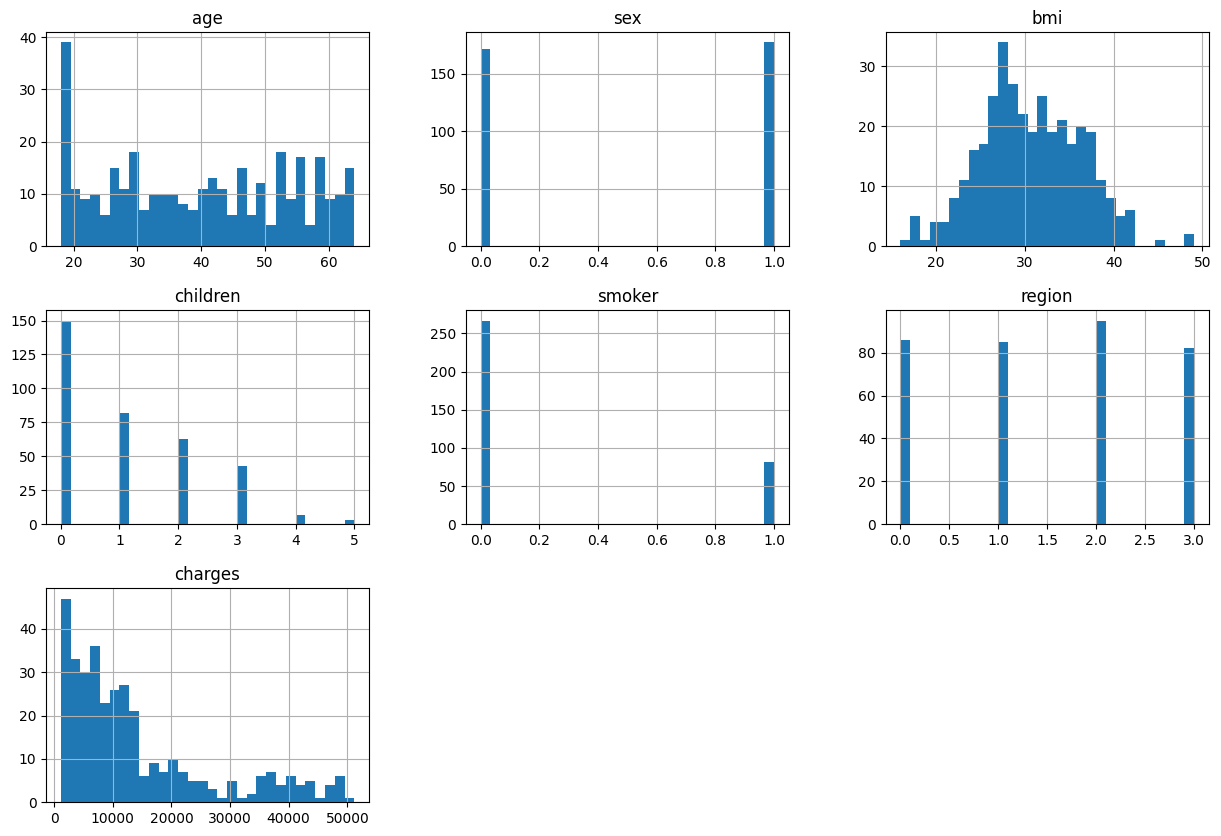

In [671]:
dados.hist(bins=30, figsize=(15,10))

Como a coluna *age* não segue uma distribuição normal, iremos normalizar e não padronizar nossos dados!

# Aplicando IA aos nossos dados

No aprendizado supervisionado temos os dados de entrada do nosso modelo $\mathbf{x}_{i}$ e também conhecemos os labels deles $\mathbf{y}_{i}$, isto é o valor esperado da saída do modelo para cada entrada

Nos dados acima o índice $i$ é utilizado para diferenciar cada uma das diferentes pessoas das quais foram levantados os dados acima. **Quais deles poderiam ser nossas entradas e nossas saídas?**

**A resposta para isso depende para cada caso!** Para uma empresa que vende seguros, o ideal é ter um modelo que dado os seguintes atributos: **[sex, bmi, children, smoker, region]** eles possam calcular o valor que será cobrado do seguro para essa pessoa **[charges]**

A imagem a seguir ilustra esse exemplo de divisão de entradas e saídas.


<center>
<img src="https://drive.google.com/uc?export=view&id=1Yvziu9GlD5W-j-Zr1EJ3LAgY_yxbViYU" width="500">

Assim podemos criar um modelo que será treinado para fazer predições do valor de saída ($\hat{\mathbf{y}}_{i}$). O esquema para esse tipo de aprendizado supervisionado pode ser vizualizado a seguir:

<center>
<img src="https://drive.google.com/uc?export=view&id=1hFdoJXTk2jTR3zupjjqlr0dOKuaeOZCE" width="500">


A ideia acima parece muito interessante para criação de diversos modelos e pode ser utilizada em diferentes aplicações.

Entretanto, seria interessante ter uma ideia do quão bom é o nosso modelo, isto é, será que o modelo que criamos tem uma boa capacidade para estimar a sua saída ($\hat{\mathbf{y}}_{i}$) para novos dados?

O que estamos perguntando acima é a verificação da capacidade de generalização do nosso modelo, isto é, a capacidade do modelo de conseguir boas estimativas de saídas para novos dados.

## Divisão dos conjuntos de dados

Pensando na pergunta acima, existem duas possibilidades de soluções:



*   Poderíamos treinar um modelo com todos os nossos dados e vender o resultado disso para um empresa. A empresa posteriormente diria se o modelo está tendo um bom desempenho ou não. **Cenário ruim: Caso o modelo não esteja com um bom desempenho iriamos prejudicar o nome da empresa**
*   Poderíamos dividir os nossos dados em conjunto de treinamento e conjunto de teste. Dessa forma, treinariamos o modelo com o primeiro conjunto e poderíamos utilizar alguma métrica para avaliar o nosso modelo no segundo conjunto de dados. **Assim, teremos uma ideia do desempenho do nosso modelo antes de enviar ao cliente!**



Na imagem a seguir podemos ver o procedimento para trabalhar com o aprendizado supervisionado com a divisão dos dados em conjunto de treinamento ($\mathbf{X}_{train}$ e $\mathbf{y}_{train}$) e no conjunto de teste ($\mathbf{X}_{test}$ e $\mathbf{y}_{test}$)

<center>
<img src="https://drive.google.com/uc?export=view&id=1k3nIve0eo-zOjA48YouMHoKJOFfiabS6" width="600">




Dessa forma os nossos dados que possuem a dimensão de 348 exemplos com 6 colunas devem ser divididos em dois conjuntos para podermos trabalhar com o seu aprendizado supervisionado

## Tarefa #1: Dividindo o conjunto de dados (Entrada/Saída e Treinamento/Teste)

In [672]:
#Dividindo os dados em entrada X e saida y
X = dados.drop(columns=['charges'])
y = dados['charges']

#Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = MinMaxScaler()
scaler.fit(X_train[['age', 'bmi']])
X_train[['age', 'bmi']] = scaler.transform(X_train[['age', 'bmi']])
X_test[['age', 'bmi']] = scaler.transform(X_test[['age', 'bmi']])

No código acima pegamos os nossos dados e dividimos eles em conjunto de treinamento e teste, tendo os dados de entrada $\mathbf{X}$ e os dados de saída  $\mathbf{y}$

## Tarefa #2: Treinando os modelos

### Regressão Linear exemplo Valores do Seguro de Vida

Agora que entendemos o conceito da Regressão Linear vamos aplicar ela ao caso do seguro de vida. Vamos treinar o modelo utilizando o conjunto de dados de treinamento:

In [673]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred_RL = modelo.predict(X_test)

Agora vamos verificar os nossos valores obtidos de previsão desse modelo treinado:

In [674]:
y_pred_RL

array([12178.03484436, 13856.73017444, 27499.61521925,  9165.35849592,
        8660.10443124, 12911.76767083, 29513.85410074, 29235.09456566,
       10818.76635734, 29396.36793141, 13719.11446397, 12303.3787634 ,
        2163.31446988, 13395.85272567, -2954.97696123, 39321.97771392,
       23977.31410772,  4452.3757228 , 14737.72116459,  7638.27986615,
       34183.83292   , 13814.10934123,  6229.52694445, 35799.12988667,
       29324.35672397, 13517.9499423 ,  4880.01533125, 11551.2012566 ,
        4640.14437778, 11382.46178295, 38639.90354944, 19227.02782846,
        3131.95251309, 14681.71149441,  3575.10725775, 39516.52950341,
        5301.75582473, 27677.61676563, 13558.41157125, 11178.77718014,
        8834.75785867, 32620.19449421,  3778.98208096,  3542.2244821 ,
         336.49838955,  5773.95851056, 26691.13621432, 17865.27816176,
       13566.41217277, 29089.70654496, 13277.8868994 ,  3205.38624   ,
       11044.66017964,  9660.35413246,  9374.32518292, 40688.89453873,
      

In [675]:
y_test

255    13047.33235
114    11488.31695
314    34838.87300
268     7441.05300
167     6128.79745
          ...     
93      5729.00530
180    11735.87905
183     7419.47790
197     8516.82900
325     6600.20595
Name: charges, Length: 70, dtype: float64

### Árvores de Decisão para regressão:

In [676]:
modelo = DecisionTreeRegressor(max_depth=3)
modelo.fit(X_train, y_train)
y_pred_AD = modelo.predict(X_test)

### Random Forest para regressão:

In [677]:
modelo = RandomForestRegressor()
modelo.fit(X_train, y_train)
y_pred_RF = modelo.predict(X_test)

### Gradient Boosting Regressor:

In [678]:
modelo = GradientBoostingRegressor(min_samples_leaf=5, n_estimators=50)
modelo.fit(X_train, y_train)
y_pred_GBR = modelo.predict(X_test)

Automatizar Treinamento


In [679]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=3),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(min_samples_leaf=5, n_estimators=50)
}

y_pred = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred[nome] = modelo.predict(X_test)

In [680]:
tabela = pd.DataFrame(y_pred)
tabela['y_test'] = y_test.values
tabela.head()

,Regressão Linear,Árvore de Decisão,Random Forest,Gradient Boosting,y_test
0,12178.034844,19405.154477,22565.307627,18936.275105,13047.33235
1,13856.730174,19405.154477,17152.450152,15946.557476,11488.31695
2,27499.615219,39940.629858,39380.552332,37211.710793,34838.87300
3,9165.358496,6995.820116,7888.678845,9487.347378,7441.05300
4,8660.104431,6995.820116,6226.922398,7229.462834,6128.79745


In [681]:
metricas = tabela[['Regressão Linear', 'y_test']].copy()
metricas['erro'] = metricas['Regressão Linear'] - metricas['y_test']
metricas.head()

,Regressão Linear,y_test,erro
0,12178.034844,13047.33235,-869.297506
1,13856.730174,11488.31695,2368.413224
2,27499.615219,34838.87300,-7339.257781
3,9165.358496,7441.05300,1724.305496
4,8660.104431,6128.79745,2531.306981


In [682]:
metricas['erro quadrado'] = metricas['erro'] ** 2
metricas['erro quadrado'].mean()

np.float64(37726891.070389256)

###Tarefa #3: Métricas de desempenho dos modelos


In [683]:
metricas['Erro Absoluto'] = abs(metricas['erro'])
metricas['Erro Absoluto'].mean()

np.float64(4275.854668717766)

#### Mean Squared Error (MSE)

Mean squared error (MSE):
Em português, erro quadrático médio, essa métrica penaliza mais erros maiores, já que os erros (diferença entre o valor previsto e o correto) são elevados ao quadrado. Podemos ter dificuldade em interpretar no contexto real o que o erro obtido significa.

$MSE = \frac{1}{m}\sum^{m}_{i=1}(\hat{y}^{(i)}-y^{(i)})^{2}$

In [684]:
mean_squared_error(y_pred=y_pred['Regressão Linear'], y_true=y_test)

37726891.070389256

#### Mean absolute error (MAE):
Em português, erro absoluto médio, essa métrica basicamente faz a média do erro absoluto de cada previsão. Facilita a interpretação no modelo real, mas temos sempre que ter em mente que erros maiores (outliers) podem atrapalhar muito a ideia obtida pela média:

$MAE = \frac{1}{m}\sum^{m}_{i=1}|\hat{y}^{(i)}-y^{(i)}|$

In [685]:
mean_absolute_error(y_pred=y_pred['Regressão Linear'], y_true=y_test)

4275.854668717766

#### R<sup>2</sup>:
O erro "R quadrado" é uma métrica que varia entre -∞ e 1 e é uma razão que indica o quão bom o nosso modelo está em comparação com um modelo "naive", que faz a predição com base no valor médio do target. Quanto maior seu valor, melhor é nosso modelo com relação a esse modelo mais simplista.

In [686]:
r2_score(y_pred=y_pred['Regressão Linear'], y_true=y_test)

0.7918111887183534

$R^{2} = 1- \frac{1}{m}\frac{\sum^{m}_{i=1}(y^{(i)}-\hat{y}^{(i)})^{2}}{\sum^{m}_{i=1}(y^{(i)}-\bar{y}^{(i)})^{2}}$

#### Métricas para todos os modelos

Vamos agora obter todas as métricas dos modelos treinados para comparação:

In [687]:
for nome, preds in y_pred.items():
    print('-' * 30)
    print(f'Métricas do modelo: {nome}')
    mse = mean_squared_error(y_pred=preds, y_true=y_test)
    mae = mean_absolute_error(y_pred=preds, y_true=y_test)
    r2 = r2_score(y_pred=preds, y_true=y_test)
    print(f'Mean Squared Error: {mse}')
    print(f'Mean Absolute Error: {mae}')
    print(f'R² Score: {r2}')

------------------------------
Métricas do modelo: Regressão Linear
Mean Squared Error: 37726891.070389256
Mean Absolute Error: 4275.854668717766
R² Score: 0.7918111887183534
------------------------------
Métricas do modelo: Árvore de Decisão
Mean Squared Error: 23084002.216185026
Mean Absolute Error: 3109.3056937113743
R² Score: 0.8726152395636328
------------------------------
Métricas do modelo: Random Forest
Mean Squared Error: 24133996.943566024
Mean Absolute Error: 3004.729129517144
R² Score: 0.8668210395131278
------------------------------
Métricas do modelo: Gradient Boosting
Mean Squared Error: 20326181.560887434
Mean Absolute Error: 2767.658942622892
R² Score: 0.8878337584414051


Podemos observar que o melhor modelo (menor MAE e MSE e maior R2 score) é o Gradient Boosting Regressor

# Exercício

Vamos analisar um conjunto de dados de jogadores de Counter Striker e aplicar um modelo de regressão linear desses dados. O conjunto de dados é carregado a seguir:

In [688]:
# Importando as bibliotecas para os modelos
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.preprocessing import StandardScaler, MinMaxScaler

import seaborn as sns
import matplotlib.pyplot as plt

# Importando o pandas
import pandas as pd

# Recebendo os dados:
from googledrivedownloader import download_file_from_google_drive as gdd



# Armazenandos os dados em um DataFrame
cs_data = pd.read_csv("../data/cs_data.csv", sep = ',')

Responder os itens solicitados na sequencia:

a) Fazer a análise dos dados

In [689]:
# seu código aqui
cs_data.head()

,Player Name,Ping,Kills,Assists,Deaths,MVP,HSP,Score
0,DNB,45,38,4,20,8,42,90
1,link1n,31,22,3,17,5,54,51
2,sn0w,42,14,4,20,0,40,42
3,reedkihaddi,90,13,3,23,0,28,33
4,pEhnol,33,11,4,27,0,54,26


In [690]:
cs_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22924 entries, 0 to 22923
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Player Name  22924 non-null  object
 1   Ping         22924 non-null  int64 
 2   Kills        22924 non-null  int64 
 3   Assists      22924 non-null  int64 
 4   Deaths       22924 non-null  int64 
 5   MVP          22924 non-null  int64 
 6   HSP          22924 non-null  int64 
 7   Score        22924 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 1.4+ MB


In [691]:
cs_data.describe()

,Ping,Kills,Assists,Deaths,MVP,HSP,Score
count,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000,22924.000000
mean,49.340080,17.856002,3.738920,18.029663,2.342916,33.949834,44.720119
std,41.060362,7.222182,2.187483,4.498182,2.066631,15.233798,16.738878
min,0.000000,-4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,13.000000,2.000000,16.000000,0.000000,23.000000,34.000000
50%,44.000000,18.000000,4.000000,19.000000,2.000000,33.000000,45.000000
75%,64.000000,23.000000,5.000000,21.000000,4.000000,44.000000,56.000000
max,996.000000,64.000000,18.000000,29.000000,16.000000,100.000000,145.000000


In [692]:
cs_data.isnull().sum()

Player Name    0
Ping           0
Kills          0
Assists        0
Deaths         0
MVP            0
HSP            0
Score          0
dtype: int64

b) Fazer a análise estatística dos dados

array([[<Axes: title={'center': 'Ping'}>,
        <Axes: title={'center': 'Kills'}>,
        <Axes: title={'center': 'Assists'}>],
       [<Axes: title={'center': 'Deaths'}>,
        <Axes: title={'center': 'MVP'}>, <Axes: title={'center': 'HSP'}>],
       [<Axes: title={'center': 'Score'}>, <Axes: >, <Axes: >]],
      dtype=object)

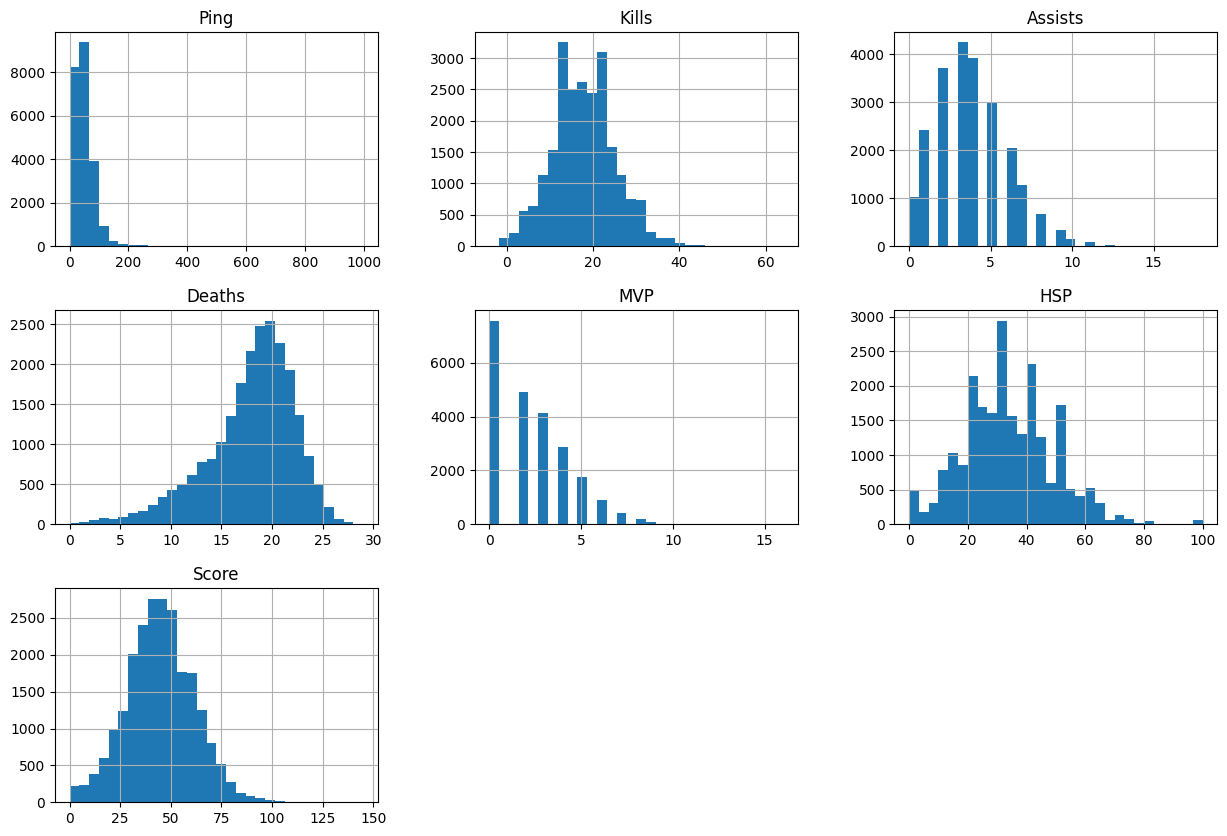

In [693]:
# seu código aqui
cs_data.hist(bins=30, figsize=(15,10))

c) Fazer a divisão dos dados em conjunto de treinamento e teste, sendo o Score o valor que desejamos como saída do modelo

Obs.: Para o conjunto de dados de entrada, excluir TAMBÉM a coluna Player id. (Essa coluna é apenas o nome dos jogadores e não possui nenhuma informação)

In [ ]:
# seu código aqui
cs_data.dropcolumns(['Player Name'], inplace=True)

In [ ]:
X = dados.drop(columns=['Score'])
y = dados['Score']

#Dividindo os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = MinMaxScaler()
scaler.fit(X_train[['age', 'bmi']])
X_train[['age', 'bmi']] = scaler.transform(X_train[['age', 'bmi']])
X_test[['age', 'bmi']] = scaler.transform(X_test[['age', 'bmi']])

d) Para os dados que foram divididos anteriormente, realizar o seu treinamento com um modelo de Regressão Linear

In [695]:
# seu código aqui

e) Fazer a previsão para o conjunto dos dados de teste

In [696]:
# seu código aqui

f) Calcular as métricas de desempenho

# Referencia Bibliográfica:



GÉRON, Aurélien. Hands-On Machine Learning with Scikit-Learn and TensorFlow. Sebastopol: O’reilly Media, 2017